In [14]:
import matplotlib
%matplotlib inline
from matplotlib import pyplot as plt

In [3]:
import sodetlib 

Rogue/pyrogue version v6.13.0. https://github.com/slaclab/rogue


# Overview

This tutorial will demonstrate using the `sodetlib` tools to stream data in `.g3` format.
Refer to the [`sodetlib` docs](https://sodetlib.readthedocs.io/en/latest/stream.html#data-taking) for details on
the functions used.

First we need to instantiate a `SmurfControl` object.

In [4]:
from sodetlib.det_config import DetConfig

cfg = DetConfig()
cfg.load_config_files(slot=4)
S = cfg.get_smurf_control()

Connected to AMCc at localhost:9012


If a resonator tune is available and they have been set up for tracking, we can proceed. Otherwise, refer
to the Tuning notebook.

## Taking data

Streaming data to G3 files is initiated with 

In [5]:
# the function returns a session ID, which can be used to track the files from this acquisition
session_id = sodetlib.stream_g3_on(S)  # see docs for optional args

[ 2026-06-09 23:17:49 ]  Fixed tones are not enabled on band 0.
[ 2026-06-09 23:17:49 ]  Fixed tones are not enabled on band 1.
[ 2026-06-09 23:17:49 ]  Fixed tones are not enabled on band 2.
[ 2026-06-09 23:17:49 ]  Fixed tones are not enabled on band 3.
[ 2026-06-09 23:17:49 ]  Fixed tones are not enabled on band 4.
[ 2026-06-09 23:17:49 ]  Fixed tones are not enabled on band 5.
[ 2026-06-09 23:17:49 ]  Fixed tones are not enabled on band 6.
[ 2026-06-09 23:17:49 ]  Fixed tones are not enabled on band 7.
[ 2026-06-09 23:17:49 ]  Input downsample factor is None. Using value already in pyrogue: 20
[ 2026-06-09 23:17:49 ]  FLUX RAMP IS DC COUPLED.
[ 2026-06-09 23:17:57 ]  Writing to file : /data/smurf_data/20260609/crate1slot4/1781047065/outputs/1781047078.dat
[ 2026-06-09 23:17:57 ]  /data/smurf_data/20260609/crate1slot4/1781047065/outputs/1781047078_mask.txt
[ 2026-06-09 23:17:58 ]  Session id: 1781047077


and interrupted with the corresponding

In [6]:
sodetlib.stream_g3_off(S)  # also returns the session ID

[ 2026-06-09 23:18:04 ]  Waiting 0.15 seconds after...
[ 2026-06-09 23:18:04 ]  Done waiting.
[ 2026-06-09 23:18:04 ]  Waiting for g3 file to close out


1781047077

For taking data over a fixed duration, use

In [7]:
session_id = sodetlib.take_g3_data(S, dur=10)  # 10s

[ 2026-06-09 23:18:17 ]  Fixed tones are not enabled on band 0.
[ 2026-06-09 23:18:17 ]  Fixed tones are not enabled on band 1.
[ 2026-06-09 23:18:17 ]  Fixed tones are not enabled on band 2.
[ 2026-06-09 23:18:17 ]  Fixed tones are not enabled on band 3.
[ 2026-06-09 23:18:17 ]  Fixed tones are not enabled on band 4.
[ 2026-06-09 23:18:17 ]  Fixed tones are not enabled on band 5.
[ 2026-06-09 23:18:17 ]  Fixed tones are not enabled on band 6.
[ 2026-06-09 23:18:17 ]  Fixed tones are not enabled on band 7.
[ 2026-06-09 23:18:17 ]  Input downsample factor is None. Using value already in pyrogue: 20
[ 2026-06-09 23:18:17 ]  FLUX RAMP IS DC COUPLED.
[ 2026-06-09 23:18:20 ]  Writing to file : /data/smurf_data/20260609/crate1slot4/1781047065/outputs/1781047100.dat
[ 2026-06-09 23:18:20 ]  /data/smurf_data/20260609/crate1slot4/1781047065/outputs/1781047100_mask.txt
[ 2026-06-09 23:18:20 ]  Session id: 1781047100
[ 2026-06-09 23:18:30 ]  Waiting 0.15 seconds after...
[ 2026-06-09 23:18:31 ]  

## Loading data

The session ID can be used to obtain the file paths associated with this acquitision.
Note that the stream ID must also be specified -- it identifies the crate/slot combination
that was used, and is stored in the `DetConfig`.

In [9]:
files = sodetlib.get_session_files(cfg.stream_id, session_id)
print(files)

['/data/so/timestreams/17810/crate1slot4/1781047100_000.g3']


The data can also be loaded directly into an `AxisManager` container in memory

In [11]:
data = sodetlib.load_session(cfg.stream_id, session_id)

In [12]:
data

AxisManager(timestamps[samps], status*[filter_pars], det_info*[dets], iir_params*, signal[dets,samps], primary*[samps], biases[bias_lines,samps], flags*[dets,samps], ch_info*[dets], dets:LabelAxis(106), samps:OffsetAxis(2325), filter_pars:IndexAxis(5), bias_lines:LabelAxis(16))

Text(0.5, 0, 'time (s)')

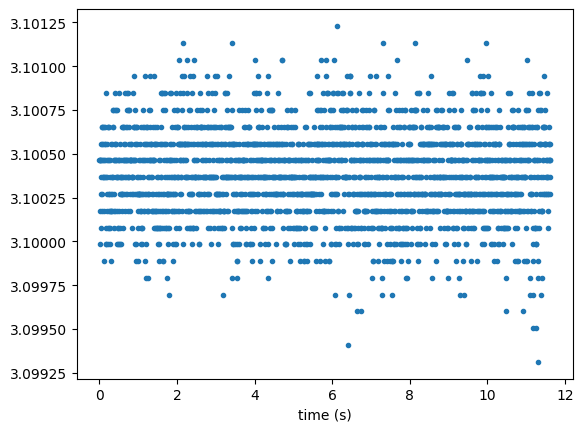

In [16]:
idx = 1
plt.plot(data.timestamps - data.timestamps[0], data.signal[idx], '.')
plt.xlabel("time (s)")